# Pipeline

In [1]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

## between 6th April to 12th April

In [2]:
np.array([0.3652,0.3801,0.5644,0.5284,0.6408,0.5907,0.5346]).mean()

np.float64(0.5148857142857144)

In [3]:
np.array([2107.32,
2239.84,
2190.3,
2190.18,
2246.18,
2285.83,
2191.8,
]).mean()

np.float64(2207.35)

In [4]:
GAS_PRICE_GWEI = 0.515        # gas price
ETH_PRICE_USD = 2207.35       # ETH价格
HEX_XLSX = "files/hex.xlsx"
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

In [5]:
def gas_to_usd(gas):
    eth = int(gas) * GAS_PRICE_GWEI * 1e-9
    return eth * ETH_PRICE_USD

def wei_to_usd(wei):
    eth = int(wei) * 1e-18
    return eth * ETH_PRICE_USD

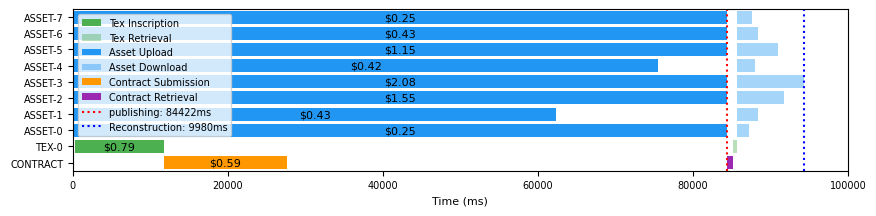

In [35]:
def draw_pipeline(json_file):
    # =========================
    # 🎨 颜色配置
    # =========================
    colors = {
        "tex": "#4CAF50",
        "asset": "#2196F3",
        "submit": "#FF9800",
        "readContract": "#9C27B0",
    }

    # =========================
    # 📥 读取 JSON
    # =========================
    with open(json_file) as f:
        data = json.load(f)
    
    lenth = len(data["texUpload"]) + len(data["assetUpload"]) + 1

    fig, ax = plt.subplots(figsize=(10, 0.21*lenth))
    

    y_labels = []
    y_pos = 0

    upload_end_all = []
    read_end_all = []
    bar_height = 0.8
    # =========================
    # 🟧 CONTRACT
    # =========================
    y_labels.append("CONTRACT")

    submit = data["submit"]
    read = data["readContract"]

    # submit
    ax.barh(y_pos, submit["end"] - submit["start"], bar_height, left=submit["start"], color=colors["submit"])
    usd = gas_to_usd(submit["gas"])
    ax.text((submit["start"] + submit["end"]) / 2, y_pos, f"${usd:.2f}", va='center', ha='center')

    upload_end_all.append(submit["end"])

    # read
    ax.barh(y_pos, read["end"] - read["start"], bar_height, left=read["start"], color=colors["readContract"])

    read_end_all.append(read["end"])

    y_pos += 1

    # =========================
    # 📗 TEX（统一颜色）
    # =========================
    for i, tex in enumerate(data["texUpload"]):
        label = f"TEX-{i}"
        y_labels.append(label)

        start = tex["start"]
        end = tex["end"]

        # 上传（深色）
        ax.barh(y_pos, end - start, bar_height, left=start, color=colors["tex"])
        usd = gas_to_usd(tex["gas"])
        ax.text((start + end) / 2, y_pos, f"${usd:.2f}", va='center', ha='center')

        upload_end_all.append(end)

        # 读取（浅色）
        rec = next((r for r in data["reconstructTex"] if r["txHash"] == tex["txHash"]), None)
        if rec:
            r_start = rec["start"]
            r_end = rec["end"]

            ax.barh(y_pos, r_end - r_start, bar_height, left=r_start, color=colors["tex"], alpha=0.4)

            read_end_all.append(r_end)

        y_pos += 1

    # =========================
    # 📘 ASSETS（统一颜色）
    # =========================
    for i, asset in enumerate(data["assetUpload"]):
        label = f"ASSET-{i}"
        y_labels.append(label)

        start = asset["start"]
        end = asset["end"]

        # 上传（深色）
        ax.barh(y_pos, end - start, bar_height, left=start, color=colors["asset"])
        usd = wei_to_usd(asset["wei"])
        ax.text((start + end) / 2, y_pos, f"${usd:.2f}", va='center', ha='center')

        upload_end_all.append(end)

        # 下载（浅色）
        ver = next((v for v in data["verifyAssets"] if v["path"] == asset["path"]), None)
        if ver:
            v_start = ver["start"]
            v_end = ver["end"]

            ax.barh(y_pos, v_end - v_start, bar_height, left=v_start, color=colors["asset"], alpha=0.4)

            read_end_all.append(v_end)

        y_pos += 1

    # =========================
    # 📏 阶段分界线
    # =========================
    upload_end = max(upload_end_all)
    read_end = max(read_end_all)

    line1 = ax.axvline(upload_end, linestyle=":", color="red", label=f"publishing: {upload_end}ms")

    line2 = ax.axvline(read_end, linestyle=":", color="blue", label=f"Reconstruction: {read_end- upload_end}ms" )

    # =========================
    # 🧾 坐标
    # =========================
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)
    ax.set_xlabel("Time (ms)")

    # =========================
    # 🧩 Legend（关键）
    # =========================

    legend_elements = [
        Patch(facecolor=colors["tex"], label="Tex Inscription"),
        Patch(facecolor=colors["tex"], alpha=0.4, label="Tex Retrieval"),
        Patch(facecolor=colors["asset"], label="Asset Upload"),
        Patch(facecolor=colors["asset"], alpha=0.4, label="Asset Download"),
        Patch(facecolor=colors["submit"], label="Contract Submission"),
        Patch(facecolor=colors["readContract"], label="Contract Retrieval"),
    ] + [line1, line2]
    ax.set_ylim(-0.5, len(y_labels) - 0.5)
    ax.set_xlim(0, 100000)
    ax.legend(handles=legend_elements, loc="upper left")
    # plt.subplots_adjust(left=0.2, right=0.95, top=0.95, bottom=0.1)
    # plt.tight_layout()
    plt.show()
draw_pipeline("files/result_t32602.22017v2.json")


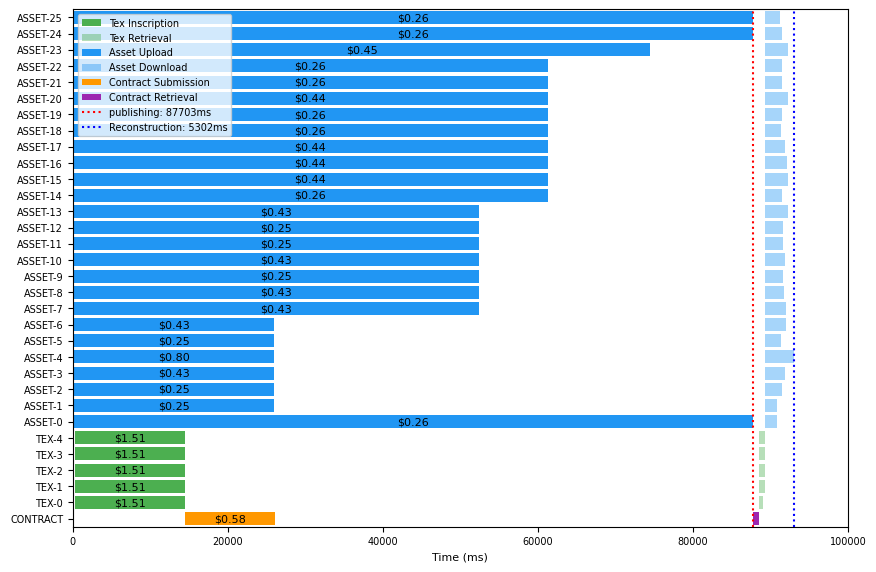

In [36]:
draw_pipeline("files/result_t32603.25100v1.json")

In [ ]:
def draw_table_from_json(json_file):
    with open(json_file) as f:
        json_data = json.load(f)
    table ="\\hline \n"
    table +=" & \\multirow{2}{*}{\\textbf{Size}(bytes)} &\\multicolumn{2}{c}{\\textbf{Cost}} & \\multicolumn{2}{c}{\\textbf{Time }(ms)} \\\\\n"
    table +=" &  &chunks & USD & submit & read \\\\\n"
    table +="\\hline \n"
    table += "\\textbf{contract}"
    table += f" & {json_data["submit"]["size"]:,} && {gas_to_usd(json_data["submit"]["gas"]):.2f} & {json_data["submit"]["end"] - json_data["submit"]["start"]:,} & {json_data["readContract"]["end"] - json_data["readContract"]["start"]:,} \\\\\n"
    table +="\\hline \n"
    for i, tex in enumerate(json_data["texUpload"]):
        read = json_data["reconstructTex"][i]
        title = ""
        if i == 0:
            length = len(json_data["texUpload"])
            title = "\\textbf{tex}" if length == 1 else f"\\multirow{{{length}}}{{*}}{{\\textbf{{tex}}}}"
        table += f" {title} & {tex["size"]:,} & &{gas_to_usd(tex["gas"]):.2f} & {tex["end"]-tex["start"]:,} & {read["end"]-read["start"]:,}\\\\\n"
    table +="\\hline \n"
    for i, obj in enumerate(json_data["assetUpload"]):
        read = json_data["verifyAssets"][i]
        title = ""
        if i == 0:
            length = len(json_data["assetUpload"])
            title = "\\textbf{asset}" if length == 1 else f"\\multirow{{{length}}}{{*}}{{\\textbf{{asset}}}}"
        table += f" {title} & {obj["size"]:,} & {obj["chunks"]} &{wei_to_usd(obj["wei"]):.2f} & {obj["end"]-obj["start"]:,} & {read["end"]-read["start"]:,}\\\\\n"
    table +="\\hline \n"

    return table

    
print(draw_table_from_json("files/result_t32602.22017v2.json"))

\hline 
 & \multirow{2}{*}{\textbf{Size}(bytes)} &\multicolumn{2}{c}{\textbf{Cost}} & \multicolumn{2}{c}{\textbf{Time }(ms)} \\
 &  &chunks & USD & submit & read \\
\hline 
\textbf{contract} & 1,124 && 0.59 & 15,859 & 800 \\
\hline 
 \textbf{tex} & 16,879 & &0.79 & 11,499 & 530\\
\hline 
 \multirow{8}{c}{\textbf{asset}} & 213 & 1 &0.25 & 84,422 & 1,453\\
  & 229,579 & 2 &0.43 & 62,389 & 2,690\\
  & 963,100 & 8 &1.55 & 84,421 & 6,001\\
  & 1,359,865 & 11 &2.08 & 84,420 & 8,647\\
  & 141,972 & 2 &0.42 & 75,554 & 2,233\\
  & 720,414 & 6 &1.15 & 84,419 & 5,208\\
  & 232,667 & 2 &0.43 & 84,419 & 2,687\\
  & 41,554 & 1 &0.25 & 84,419 & 1,841\\
\hline 



In [101]:
print(draw_table_from_json("files/result_t32603.25100v1.json"))

\hline 
 & \multirow{2}{*}{\textbf{Size}(bytes)} &\multicolumn{2}{c}{\textbf{Cost}} & \multicolumn{2}{c}{\textbf{Time }(ms)} \\
 &  &chunks & USD & submit & read \\
\hline 
\textbf{contract} & 804 && 0.58 & 11,620 & 813 \\
\hline 
 \multirow{5}{c}{\textbf{tex}} & 32,768 & &1.51 & 14,177 & 546\\
  & 32,768 & &1.51 & 14,177 & 818\\
  & 32,768 & &1.51 & 14,174 & 814\\
  & 32,768 & &1.51 & 14,177 & 816\\
  & 32,751 & &1.51 & 14,177 & 814\\
\hline 
 \multirow{26}{c}{\textbf{asset}} & 213 & 1 &0.26 & 87,703 & 1,502\\
  & 7,642 & 1 &0.25 & 26,004 & 1,491\\
  & 78,613 & 1 &0.25 & 26,003 & 2,186\\
  & 160,863 & 2 &0.43 & 26,003 & 2,544\\
  & 421,484 & 4 &0.80 & 26,002 & 3,668\\
  & 66,165 & 1 &0.25 & 26,002 & 2,052\\
  & 208,111 & 2 &0.43 & 26,001 & 2,703\\
  & 222,505 & 2 &0.43 & 52,443 & 2,703\\
  & 147,093 & 2 &0.43 & 52,443 & 2,367\\
  & 99,968 & 1 &0.25 & 52,442 & 2,267\\
  & 170,078 & 2 &0.43 & 52,442 & 2,540\\
  & 110,914 & 1 &0.25 & 52,441 & 2,321\\
  & 116,937 & 1 &0.25 & 52,441 & 2,32

In [27]:
def size_to_gas(size):
    return 40.412873 * size + 12950.14
size_to_gas(693025)

28020081.450825

In [28]:
gas_to_usd(28020081.450825)

31.85281478460525

In [29]:
1 - 7.55 / 31.85

0.7629513343799058

In [17]:
wei_to_usd(4160231082920017)

9.1830860808835

In [13]:
15859 + 11499

27358

In [36]:
def calculateusd(json_file):
    """
    简化版LaTeX表格生成器
    """
    with open(json_file) as f:
        json_data = json.load(f)
    assets = json_data["assetUpload"]
    texs = json_data["texUpload"]
    wei = 0
    gas = 0
    contract = int(json_data["submit"]["gas"])
    for tex in texs:
        gas += int(tex["gas"])
    for asset in assets:
        wei += int(asset["wei"])

    tex_time = max(item["end"]-item["start"] for item in json_data["texUpload"])
    rtex_time = max(item["end"]-item["start"] for item in json_data["reconstructTex"])
    tex_max_size = max(item["size"] for item in json_data["texUpload"])

    asset_time = max(item["end"]-item["start"] for item in json_data["assetUpload"])
    rasset_time = max(item["end"]-item["start"] for item in json_data["verifyAssets"])
    asset_max_size = max(item["size"] for item in json_data["assetUpload"])

    return {
        "contect": {
            "gas": contract,
            "usd": gas_to_usd(contract),
            "size": json_data["submit"]["size"],
            "time": json_data["submit"]["end"] - json_data["submit"]["start"],
            "rtime": json_data["readContract"]["end"] - json_data["readContract"]["start"]
        },
        "tex": {
            "gas": gas,
            "usd": gas_to_usd(gas),
            "count": len(texs),
            "tex_max_size": tex_max_size,
            "time": tex_time,
            "rtime":rtex_time
        },
        "assets": {
            "wei": wei,
            "usd": wei_to_usd(wei),
            "count": len(assets),
            "asset_max_size": asset_max_size,
            "time": asset_time,
            "rtime":rasset_time
        }
    }
calculateusd("files/result_t32602.22017v2.json")

{'contect': {'gas': 516808,
  'usd': 0.587499711482,
  'size': 1124,
  'time': 15859,
  'rtime': 800},
 'tex': {'gas': 694360,
  'usd': 0.7893382061900001,
  'count': 1,
  'tex_max_size': 16879,
  'time': 11499,
  'rtime': 530},
 'assets': {'wei': 2965815726404761,
  'usd': 6.546593343679549,
  'count': 8,
  'asset_max_size': 1359865,
  'time': 84422,
  'rtime': 8647}}

In [37]:
calculateusd("files/result_t32603.25100v1.json")

{'contect': {'gas': 514114,
  'usd': 0.5844372120185001,
  'size': 804,
  'time': 11620,
  'rtime': 813},
 'tex': {'gas': 6638060,
  'usd': 7.546048696615,
  'count': 5,
  'tex_max_size': 32768,
  'time': 14177,
  'rtime': 818},
 'assets': {'wei': 4160231082920017,
  'usd': 9.1830860808835,
  'count': 26,
  'asset_max_size': 421484,
  'time': 87703,
  'rtime': 3668}}

In [24]:
gas_to_usd(514114 + 6638060) + wei_to_usd(4160231082920017)

17.313571989517

In [43]:
def get_row_by_id(id:str):
    df = pd.read_excel(HEX_XLSX)
    return df[df["id"]==id].iloc[0]
get_row_by_id("2603.25100v1")

FileNotFoundError: [Errno 2] No such file or directory: 'files/hex.xlsx'

In [25]:
gas_to_usd(size_to_gas(60928))

2.81379927043125

In [22]:
get_row_by_id("2603.25100v1")

Unnamed: 0                                                          20
id                                                        2603.25100v1
title                From Logic Monopoly to Social Contract: Separa...
original_size                                                   693025
compressed_size                                                 163799
encrypted_size                                                  163824
key_encrypt_time                                              0.000199
key_decrypt_time                                              0.000513
text_encrypt_time                                             0.000265
text_decrypt_time                                             0.000092
zerobytes                                                          662
Name: 20, dtype: object

In [26]:
gas_to_usd(size_to_gas(693025))

31.85281478460525